## Dataset: Cardekho

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# ---------------------------------------------------
# Load data
# ---------------------------------------------------

df = pd.read_csv("https://raw.githubusercontent.com/tech4alltraining/aiml/refs/heads/main/datasets/regression/cardekho_preprocessed.csv")

# ---------------------------------------------------
# Target variable
# ---------------------------------------------------

y = df["selling_price"]


In [ ]:

# ===================================================
# MODEL 1 : UNDERFITTING
# Uses only one feature + very shallow tree
# ===================================================

X_underfit = df[["vehicle_age"]]

X_train, X_test, y_train, y_test = train_test_split(
    X_underfit,
    y,
    test_size=0.2,
    random_state=42
)

underfit_model = DecisionTreeRegressor(
    max_depth=1,
    random_state=42
)

underfit_model.fit(X_train, y_train)

train_pred = underfit_model.predict(X_train)
test_pred = underfit_model.predict(X_test)

print("\n" + "="*60)
print("UNDERFITTING MODEL")
print("="*60)
print("Features Used: vehicle_age")
print("Train R²:", round(r2_score(y_train, train_pred), 4))
print("Test  R²:", round(r2_score(y_test, test_pred), 4))



UNDERFITTING MODEL
Features Used: vehicle_age
Train R²: 0.0381
Test  R²: 0.0497


In [ ]:
# ===================================================
# MODEL 2 : GOOD FIT
# Uses important numerical features
# ===================================================

good_features = [
    "vehicle_age",
    "km_driven",
    "engine",
    "max_power"
]

X_good = df[good_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_good,
    y,
    test_size=0.2,
    random_state=42
)

good_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

good_model.fit(X_train, y_train)

train_pred = good_model.predict(X_train)
test_pred = good_model.predict(X_test)

print("\n" + "="*60)
print("GOOD FIT MODEL")
print("="*60)
print("Features Used:", good_features)
print("Train R²:", round(r2_score(y_train, train_pred), 4))
print("Test  R²:", round(r2_score(y_test, test_pred), 4))




GOOD FIT MODEL
Features Used: ['vehicle_age', 'km_driven', 'engine', 'max_power']
Train R²: 0.7961
Test  R²: 0.7726


In [ ]:

# ===================================================
# MODEL 3 : OVERFITTING
# Uses many numerical features + unrestricted tree
# ===================================================

overfit_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

X_overfit = df[overfit_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_overfit,
    y,
    test_size=0.2,
    random_state=42
)

overfit_model = DecisionTreeRegressor(
    max_depth=None,
    min_samples_leaf=1,
    random_state=42
)

overfit_model.fit(X_train, y_train)

train_pred = overfit_model.predict(X_train)
test_pred = overfit_model.predict(X_test)

print("\n" + "="*60)
print("OVERFITTING MODEL")
print("="*60)
print("Features Used:", overfit_features)
print("Train R²:", round(r2_score(y_train, train_pred), 4))
print("Test  R²:", round(r2_score(y_test, test_pred), 4))




OVERFITTING MODEL
Features Used: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
Train R²: 0.9993
Test  R²: 0.2477


In [ ]:

# ===================================================
# SUMMARY
# ===================================================

print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)

print("""
Underfitting:
    Low Train R²
    Low Test R²
    Model too simple

Good Fit:
    High Train R²
    High Test R²
    Small difference between them

Overfitting:
    Very High Train R²
    Lower Test R²
    Large gap between Train and Test performance
""")


INTERPRETATION

Underfitting:
    Low Train R²
    Low Test R²
    Model too simple

Good Fit:
    High Train R²
    High Test R²
    Small difference between them

Overfitting:
    Very High Train R²
    Lower Test R²
    Large gap between Train and Test performance



## Dataset: Heart Failure Clinical Records - Tree Choice

In [ ]:
# Dataset: Heart Failure Clinical Records

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [ ]:
# ----------------------------------------------------
# 1. Load dataset
# ----------------------------------------------------

url = "https://raw.githubusercontent.com/sauravmishra1710/Heart-Failure-Condition-And-Survival-Analysis/master/Data/heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(url)
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [ ]:

# ----------------------------------------------------
# 2. Split features and target
# ----------------------------------------------------

X = df.drop(columns=["DEATH_EVENT"])
y = df["DEATH_EVENT"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
# 3. Split the data (80% training, 20% testing)
# We use a fixed random_state so the demonstration is reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

# ----------------------------------------------------
# 5. Display comparison table
# ----------------------------------------------------

results_df = pd.DataFrame(results)
print("\nFinal Comparison:")
print(results_df)


Final Comparison:
                Model  Train Accuracy  Test Accuracy  Train F1   Test F1
0  Underfitting Model        0.849372       0.833333  0.746479  0.666667
1      Good Fit Model        0.882845       0.833333  0.813333  0.687500
2   Overfitting Model        1.000000       0.733333  1.000000  0.529412


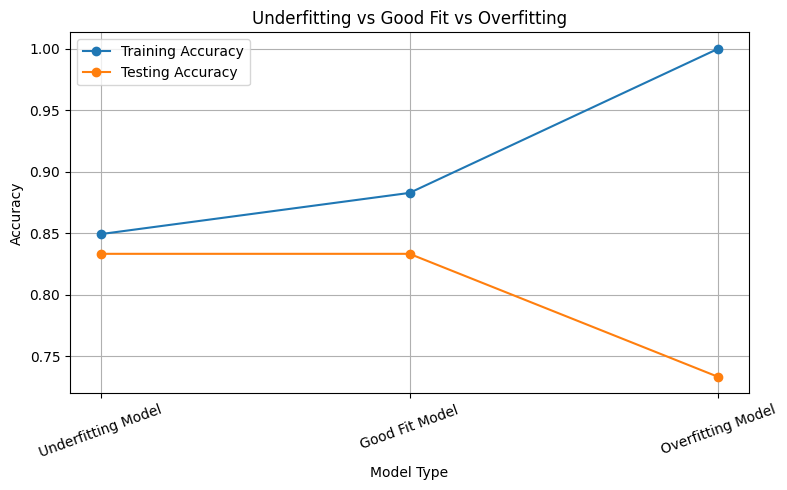

In [ ]:

# ----------------------------------------------------
# 6. Plot train vs test accuracy
# ----------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Model"],
    results_df["Train Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    results_df["Model"],
    results_df["Test Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Model Type")
plt.ylabel("Accuracy")
plt.title("Underfitting vs Good Fit vs Overfitting")
plt.xticks(rotation=20)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()